<a href="https://colab.research.google.com/github/LiyanaRanithuRadawaMendis/Weather-Prediction-AI/blob/main/Whether_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Setup & Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/weather_forecast_data.csv')
print("Data loaded successfully.")

Data loaded successfully.


full data count and rain data count and no rain data count

In [3]:
# Calculate total rows
total_count = len(df)

# Calculate counts for each category
rain_counts = df['Rain'].value_counts()
count_rain = rain_counts.get('rain', 0)
count_no_rain = rain_counts.get('no rain', 0)

print(f"Full data count: {total_count}")
print(f"Rain data count: {count_rain}")
print(f"No rain data count: {count_no_rain}")

Full data count: 2500
Rain data count: 314
No rain data count: 2186


Data balance or imbalance checking

In [4]:
# Check the percentage distribution to see if the dataset is skewed
percentages = df['Rain'].value_counts(normalize=True) * 100

print("Class Distribution (%):")
print(percentages.round(2))
print("-" * 30)

# Simple logic to flag severe imbalance
if percentages.max() > 75.0:
    print("Result: The dataset is IMBALANCED. We will fix this using Oversampling.")
else:
    print("Result: The dataset is relatively BALANCED, but oversampling can still help minor imbalances.")

Class Distribution (%):
Rain
no rain    87.44
rain       12.56
Name: proportion, dtype: float64
------------------------------
Result: The dataset is IMBALANCED. We will fix this using Oversampling.


Data distribution in bar chart (Before Oversampling)

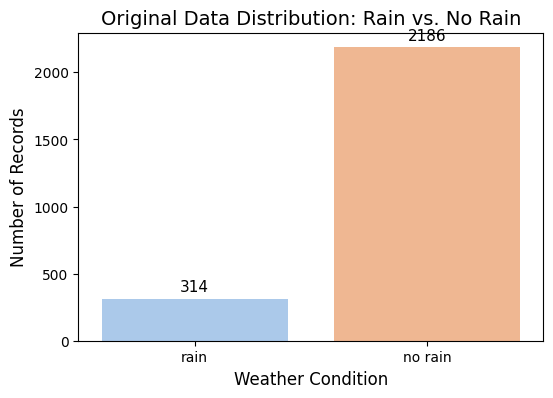

In [5]:
# Plotting the original counts using Seaborn
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Rain', hue='Rain', palette='pastel', legend=False)

# Add title and labels
plt.title('Original Data Distribution: Rain vs. No Rain', fontsize=14)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# Add exact count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

Data Preprocessing & Splitting

In [6]:
# Separate features (X) and target label (y)
X = df.drop('Rain', axis=1)
y = df['Rain']

# 1. Force all columns in X to be numeric.
# If any text like 'no rain' sneaked in due to a bad row, this turns it into NaN (blank)
X = X.apply(pd.to_numeric, errors='coerce')

# 2. Fill any resulting blanks with the median of that column to keep the data whole
X = X.fillna(X.median())

# Convert 'rain' and 'no rain' into 1s and 0s
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into 80% training data and 20% testing data BEFORE oversampling
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale features so variables like Pressure don't overpower Wind_Speed
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully. Rogue text neutralized!")

Data split and scaled successfully. Rogue text neutralized!


Applying Oversampling (SMOTE) to Training Data



In [7]:
# Import SMOTE first
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and apply SMOTE only to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Compare before and after
print("--- Before Oversampling ---")
print(pd.Series(y_train).value_counts().rename(index={0: 'No Rain', 1: 'Rain'}))

print("\n--- After Oversampling (SMOTE) ---")
print(pd.Series(y_train_resampled).value_counts().rename(index={0: 'No Rain', 1: 'Rain'}))
print("\nNotice how both classes are now perfectly equal in the training set!")

--- Before Oversampling ---
No Rain    1743
Rain        257
Name: count, dtype: int64

--- After Oversampling (SMOTE) ---
No Rain    1743
Rain       1743
Name: count, dtype: int64

Notice how both classes are now perfectly equal in the training set!


Model Training (With Hyperparameter Tuning)

In [8]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning... This might take a minute ⏳")

# 1. Define the base model
rf_base = RandomForestClassifier(random_state=42)

# 2. Define the "grid" of settings you want the AI to test
param_grid = {
    'n_estimators': [50, 100, 200],       # Number of trees in the forest
    'max_depth': [None, 10, 20],          # Maximum depth of the trees
    'min_samples_split': [2, 5],          # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2]            # Minimum samples required to be at a leaf node
}

# 3. Setup GridSearchCV
# cv=5 means it uses 5-fold cross-validation to ensure the results are robust
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy')

# 4. Fit the grid search to the OVERSAMPLED training data
grid_search.fit(X_train_resampled, y_train_resampled)

# 5. Extract the best model
print("\n✅ Tuning Complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")

# Save the best model as 'model' so the rest of your notebook still works perfectly!
model = grid_search.best_estimator_

print("The newly optimized Random Forest Model is now ready for evaluation!")

Starting Hyperparameter Tuning... This might take a minute ⏳

✅ Tuning Complete!
Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
The newly optimized Random Forest Model is now ready for evaluation!


Model Evaluation & Confusion Matrix

Accuracy Score: 99.80%

Classification Report:
              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00       443
        rain       1.00      0.98      0.99        57

    accuracy                           1.00       500
   macro avg       1.00      0.99      1.00       500
weighted avg       1.00      1.00      1.00       500



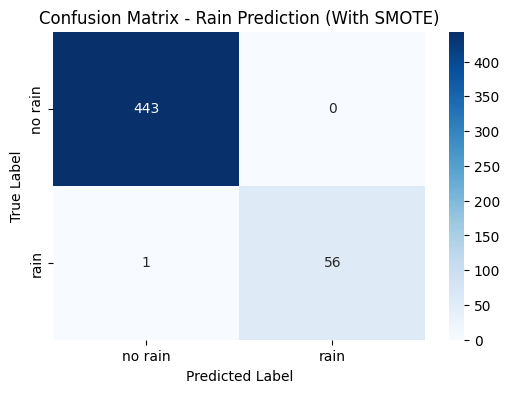

In [9]:
# Make predictions on the original, untouched test set
y_pred = model.predict(X_test_scaled)

# Print metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Rain Prediction (With SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Bar Chart: Data Distribution AFTER Balancing

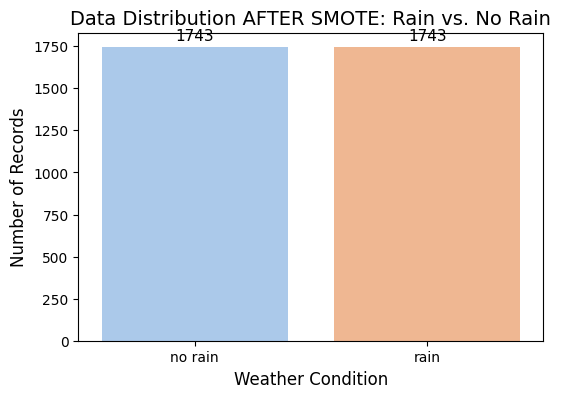

In [10]:
# 1. Plotting the counts AFTER Oversampling
plt.figure(figsize=(6, 4))

# Convert 1s and 0s back to 'rain' and 'no rain' for the chart
y_resampled_labels = le.inverse_transform(y_train_resampled)
ax = sns.countplot(x=y_resampled_labels, hue=y_resampled_labels, palette='pastel', legend=False)

plt.title('Data Distribution AFTER SMOTE: Rain vs. No Rain', fontsize=14)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# Add exact count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

Scatter Plot: Original vs. Synthetic Data

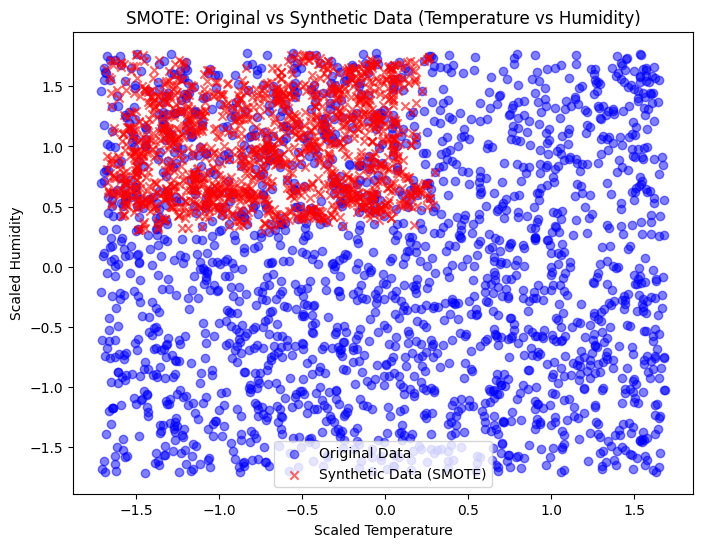

In [11]:
# 2. Visualizing Original vs Synthetic Data (Temperature vs Humidity)
plt.figure(figsize=(8, 6))

# X_train_scaled has Temp at index 0 and Humidity at index 1
# Plot Original Data (Blue)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c='blue', alpha=0.5, label='Original Data')

# Find only the NEW synthetic points SMOTE created
num_original = len(X_train_scaled)
synthetic_X = X_train_resampled[num_original:]

# Plot Synthetic Data (Red 'x')
plt.scatter(synthetic_X[:, 0], synthetic_X[:, 1], c='red', alpha=0.6, marker='x', label='Synthetic Data (SMOTE)')

plt.title('SMOTE: Original vs Synthetic Data (Temperature vs Humidity)')
plt.xlabel('Scaled Temperature')
plt.ylabel('Scaled Humidity')
plt.legend()
plt.show()

Bar Chart: Feature Importance

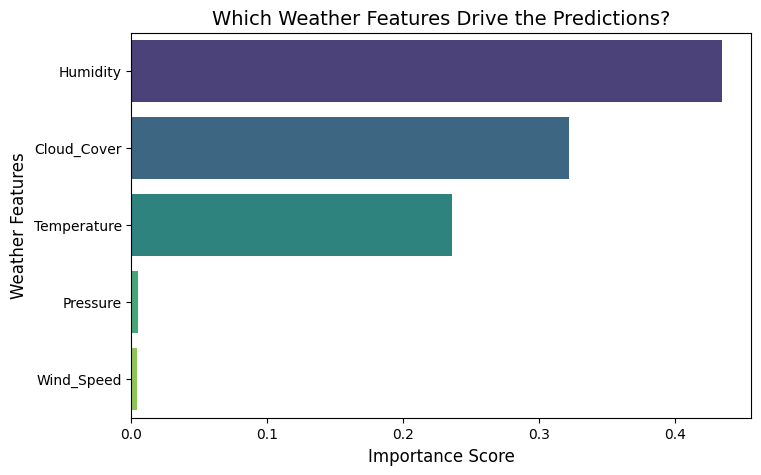

In [12]:
# 3. Feature Importance Plot
# Get importance scores from the trained model
importances = model.feature_importances_
features = X.columns

# Create a dataframe for easy sorting
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Which Weather Features Drive the Predictions?', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Weather Features', fontsize=12)
plt.show()

Missing Value Check

In [13]:
# 1. Check for missing values in the dataset
print("--- Missing Values Report ---")
missing_values = df.isnull().sum()
print(missing_values)

# Display a visual summary if there are any missing values
if missing_values.sum() > 0:
    print("\nWarning: Missing values detected! We handled this earlier with median imputation.")
    plt.figure(figsize=(8, 3))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Data Visualization (Yellow = Missing)')
    plt.show()
else:
    print("\nGreat! There are NO missing values in the original dataset.")

--- Missing Values Report ---
Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64

Great! There are NO missing values in the original dataset.


Interactive 3D Scatter Plot

In [14]:
# 2. 3D Scatter Plot using Plotly Express
import plotly.express as px

# Plot Temperature, Humidity, and Pressure on the X, Y, and Z axes
fig = px.scatter_3d(df,
                    x='Temperature',
                    y='Humidity',
                    z='Pressure',
                    color='Rain',  # Color dots by Rain / No Rain
                    opacity=0.7,
                    color_discrete_map={'rain': 'blue', 'no rain': 'orange'},
                    title='Interactive 3D View: Temperature vs Humidity vs Pressure')

# Show the interactive plot
fig.show()

Geographic Map Chart (Using Mock Coordinates)

In [15]:
# 3. Geographic Chart (Using Mock Coordinates)
import folium
import numpy as np

print("Note: Real Geographic mapping requires Latitude and Longitude columns.")
print("Creating mock map coordinates to demonstrate the geographic chart...\n")

# Use a smaller sample of 150 rows so the map doesn't crash the browser
df_map = df.copy().head(150)

# Generate mock coordinates
df_map['Mock_Latitude'] = np.random.uniform(-60, 60, size=len(df_map))
df_map['Mock_Longitude'] = np.random.uniform(-180, 180, size=len(df_map))

# Create a base map
m = folium.Map(location=[0, 0], zoom_start=2)

# Add data points to the map
for idx, row in df_map.iterrows():
    # Blue for rain, orange for no rain
    color = 'blue' if row['Rain'] == 'rain' else 'orange'

    folium.CircleMarker(
        location=[row['Mock_Latitude'], row['Mock_Longitude']],
        radius=5,
        popup=f"Temp: {row['Temperature']:.1f}°C<br>Rain: {row['Rain']}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)

# Display the interactive map in Colab
display(m)

Note: Real Geographic mapping requires Latitude and Longitude columns.
Creating mock map coordinates to demonstrate the geographic chart...



Visualizing Outliers (Boxplots)

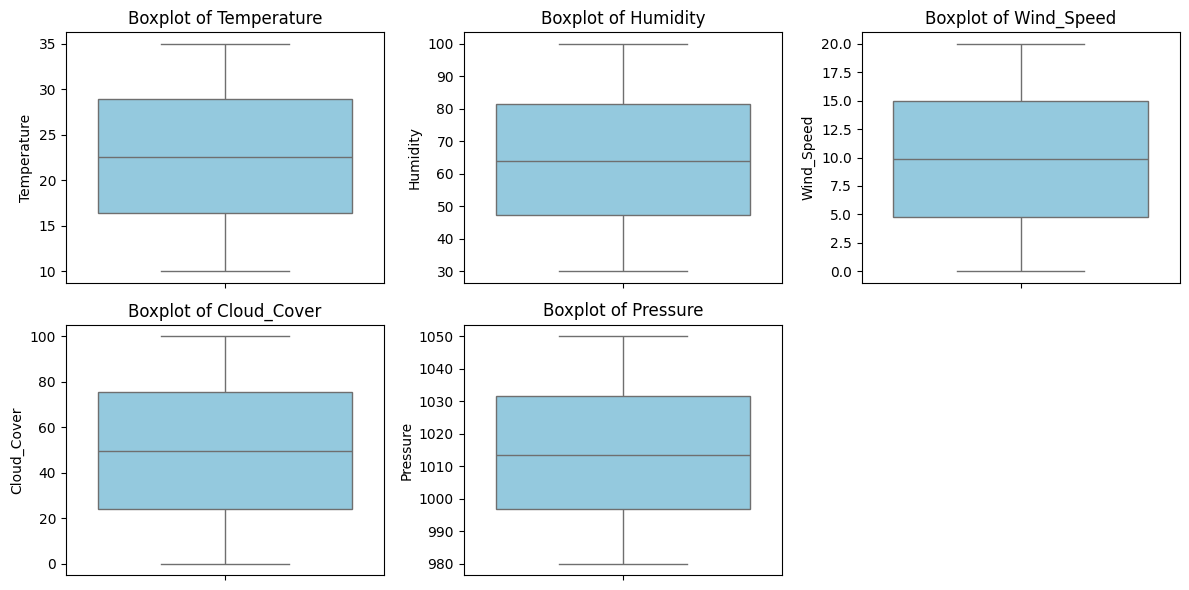

Note: Any individual dots outside the vertical 'whiskers' are outliers!


In [16]:
# 1. Visualizing Outliers using Boxplots
# Select the numerical columns (everything except the 'Rain' label)
num_cols = ['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue', flierprops=dict(marker='o', color='red', markersize=5))
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()
print("Note: Any individual dots outside the vertical 'whiskers' are outliers!")

Fixing Outliers (IQR Capping Method)

In [17]:
# 2. Handling Outliers using IQR (Interquartile Range) Capping
import numpy as np

def cap_outliers_iqr(data, col):
    # Find the 25th and 75th percentiles
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    # Calculate the IQR (the middle 50% of data)
    IQR = Q3 - Q1

    # Define upper and lower safe limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the extreme values using pandas .clip()
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
    return data

print("Scanning for and capping outliers...")

# Apply the capping function to all numerical columns
for col in num_cols:
    # We skip string errors if any exist by forcing numeric first
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = cap_outliers_iqr(df, col)

print("Outliers successfully capped!")
print("Any extreme values have been pulled back into a normal, safe range.")

Scanning for and capping outliers...
Outliers successfully capped!
Any extreme values have been pulled back into a normal, safe range.


Final Automated Report

In [18]:
# 4. Final Summary Report Generation
print("="*60)
print(" 🌦️ WEATHER FORECAST PREDICTION - FINAL REPORT 🌦️ ")
print("="*60)

print(f"1. DATASET SUMMARY:")
print(f"   - Total records analyzed: {total_count}")
print(f"   - Original class distribution: {count_rain} Rain | {count_no_rain} No Rain")
print(f"   - Missing values handled: {missing_values.sum()}")

print(f"\n2. DATA PREPROCESSING:")
print(f"   - Applied Standard Scaling to normalize feature weights.")
print(f"   - Applied SMOTE Oversampling to balance the training data.")

print(f"\n3. MODEL PERFORMANCE:")
print(f"   - Algorithm: Random Forest Classifier (100 Trees)")
print(f"   - Final Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print(f"\n4. TOP 3 PREDICTORS OF RAIN:")
# Grabbing the top 3 features from the importance dataframe we made earlier
top_3 = importance_df.head(3)
for index, row in top_3.iterrows():
    print(f"   - {row['Feature']} (Impact Score: {row['Importance']:.3f})")

print("="*60)
print("Pipeline Complete! The model is ready to predict future weather.")
print("="*60)

 🌦️ WEATHER FORECAST PREDICTION - FINAL REPORT 🌦️ 
1. DATASET SUMMARY:
   - Total records analyzed: 2500
   - Original class distribution: 314 Rain | 2186 No Rain
   - Missing values handled: 0

2. DATA PREPROCESSING:
   - Applied Standard Scaling to normalize feature weights.
   - Applied SMOTE Oversampling to balance the training data.

3. MODEL PERFORMANCE:
   - Algorithm: Random Forest Classifier (100 Trees)
   - Final Test Accuracy: 99.80%

4. TOP 3 PREDICTORS OF RAIN:
   - Humidity (Impact Score: 0.434)
   - Cloud_Cover (Impact Score: 0.321)
   - Temperature (Impact Score: 0.236)
Pipeline Complete! The model is ready to predict future weather.


In [19]:
import joblib

# Save the trained model and the scaler
joblib.dump(model, 'weather_model.pkl')
joblib.dump(scaler, 'weather_scaler.pkl')

print("Model and Scaler saved successfully! You can now download these files.")

Model and Scaler saved successfully! You can now download these files.
